<a href="https://colab.research.google.com/github/ftkals/Traffic_Risk_Analyser/blob/main/TrafficRiskAnalyserCA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚦 Traffic Risk Analyser
**Dataset:** [UK Road Safety – Accidents and Vehicles](https://www.kaggle.com/datasets/tsiaras/uk-road-safety-accidents-and-vehicles)

**Course:** Data Pre-processing & EDA Lab (0701260207) | **Batch:** 2025-29

---
#Data Understanding

### 1. Problem Statement
Road accidents cause thousands of preventable deaths and injuries annually in the UK.
Despite rich historical data, the patterns behind accident severity — speed limits, lighting,
road type, weather — are rarely analysed systematically.

**Traffic Risk Analyser** applies a complete data pre-processing and EDA pipeline to the
UK Road Safety dataset to identify key risk factors contributing to fatal, serious, and
slight accidents. The insights support road safety policy, urban planning, and traffic
management decisions.



### 2. Dataset Description

**Source:** Kaggle – UK Road Safety: Accidents and Vehicles (UK Dept. for Transport)

**File:** `Accident_Information.csv`

**Key Attributes:**

| Attribute | Type | Role |
|---|---|---|
| `Accident_Severity` | Integer (1–3) | **Target Variable** (1=Fatal, 2=Serious, 3=Slight) |
| `Number_of_Casualties` | Integer | Numerical feature |
| `Number_of_Vehicles` | Integer | Numerical feature |
| `Speed_limit` | Integer | Numerical feature |
| `Date`, `Time` | String | Temporal features |
| `Road_Type` | Categorical | Environmental factor |
| `Light_Conditions` | Categorical | Environmental factor |
| `Weather_Conditions` | Categorical | Environmental factor |
| `Road_Surface_Conditions` | Categorical | Environmental factor |
| `Urban_or_Rural_Area` | Binary | Location context |





### 3. Initial Observations & Data Issues Identified

**Observations:**
- Dataset is heavily **class-imbalanced** — ~84% Slight, ~14% Serious, ~2% Fatal
- Missing values are **encoded as -1** (sentinel values), not standard NaN
- `Date` and `Time` are stored as strings — require type conversion

**Issues Identified:**

| Issue | Treatment |
|---|---|
| Sentinel -1 values | Replace with `NaN` before imputation |
| Missing values | Median (numeric), Mode (categorical), k-NN imputation |
| Wrong data types | Convert `Date` → datetime, extract `Hour` from `Time` |
| Invalid speed limits | Values outside {20, 30, 40, 50, 60, 70} replaced via mode |
| Duplicate rows | Removed using `drop_duplicates()` |
| Outliers in casualties/vehicles | Detected via IQR & Z-score
| String whitespace | Stripped using `.str.strip()` |

---
# Data Acquisition
- Load CSV data from google drive
- Inspect raw data
- Understand dataset structure

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading dataset:
df= pd.read_csv("/content/drive/MyDrive/dpel mini project ca3/dataset/Accident_Information.csv")

/tmp/ipykernel_8843/717483528.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("/content/drive/MyDrive/dpel mini project ca3/dataset/Accident_Information.csv")


In [ ]:
# top 5 rows:
df.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [ ]:
# info:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               object 
 1   1st_Road_Class                               object 
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               object 
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            object 
 6   Carriageway_Hazards                          object 
 7   Date                                         object 
 8   Day_of_Week                                  object 
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             object 
 11  Junction_Detail                              object 
 12  Latitude                                     float64
 13  Light_Condit

In [ ]:
# describe:
df.describe()

,1st_Road_Number,2nd_Road_Number,Did_Police_Officer_Attend_Scene_of_Accident,Latitude,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Speed_limit,Year
count,2.047254e+06,2.029663e+06,2.046978e+06,2.047082e+06,2.047092e+06,2.047092e+06,2.047081e+06,2.047256e+06,2.047256e+06,2.044336e+06,2.043696e+06,2.047219e+06,2.047256e+06
mean,9.921051e+02,3.728153e+02,1.202319e+00,5.255978e+01,4.414462e+05,2.968855e+05,-1.410155e+00,1.345843e+00,1.833525e+00,1.041707e-02,7.518021e-01,3.884360e+01,2.010524e+03
std,1.809408e+03,1.287796e+03,4.081935e-01,1.445506e+00,9.549620e+04,1.605273e+05,1.403532e+00,8.179627e-01,7.150543e-01,1.351126e-01,1.835289e+00,1.414791e+01,3.765624e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,4.991294e+01,6.495000e+04,1.029000e+04,-7.516225e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.005000e+03
25%,0.000000e+00,0.000000e+00,1.000000e+00,5.148540e+01,3.780635e+05,1.777568e+05,-2.329610e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,2.007000e+03
50%,1.180000e+02,0.000000e+00,1.000000e+00,5.223758e+01,4.430500e+05,2.611835e+05,-1.362233e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,2.010000e+03
75%,7.020000e+02,0.000000e+00,1.000000e+00,5.345590e+01,5.242982e+05,3.956100e+05,-2.052600e-01,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,2.014000e+03
max,9.999000e+03,9.999000e+03,3.000000e+00,6.075754e+01,6.555400e+05,1.208800e+06,1.762010e+00,9.300000e+01,6.700000e+01,2.000000e+00,8.000000e+00,7.000000e+01,2.017000e+03


In [ ]:
# shape:
df.shape

(2047256, 34)

In [ ]:
# columns:
df.columns

Index(['Accident_Index', '1st_Road_Class', '1st_Road_Number', '2nd_Road_Class',
       '2nd_Road_Number', 'Accident_Severity', 'Carriageway_Hazards', 'Date',
       'Day_of_Week', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'Junction_Control', 'Junction_Detail', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'LSOA_of_Accident_Location', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Special_Conditions_at_Site',
       'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Year', 'InScotland'],
      dtype='object')

In [ ]:
# segregating numerical cols and categorical cols
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("numerical cols:", numeric_cols)
print("categorical cols:", categorical_cols)

numerical cols: Index(['1st_Road_Number', '2nd_Road_Number',
       'Did_Police_Officer_Attend_Scene_of_Accident', 'Latitude',
       'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Speed_limit', 'Year'],
      dtype='object')
categorical cols: Index(['Accident_Index', '1st_Road_Class', '2nd_Road_Class',
       'Accident_Severity', 'Carriageway_Hazards', 'Date', 'Day_of_Week',
       'Junction_Control', 'Junction_Detail', 'Light_Conditions',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'LSOA_of_Accident_Location', 'Police_Force', 'Road_Surface_Conditions',
       'Road_Type', 'Special_Conditions_at_Site', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'InScotland'],
      dtype='object')


---
# Handling missing values
*   checking null values
*   removing whitspaces from categorical columns
*   imputation using median, mode and KNN methods

In [ ]:
# replacing -1 with NaN values (if -1 would be entered for null values)
df[numeric_cols] = df[numeric_cols].replace(-1, np.nan)

In [ ]:
# stripping off whitespaces from the categorical columns
df[categorical_cols] = df[categorical_cols].apply(lambda col: col.str.strip())

In [ ]:
# nan/null values in each column.
df.isnull().sum()

,0
Accident_Index,32768
1st_Road_Class,0
1st_Road_Number,2
2nd_Road_Class,844272
2nd_Road_Number,17593
Accident_Severity,0
Carriageway_Hazards,2007807
Date,0
Day_of_Week,0
Did_Police_Officer_Attend_Scene_of_Accident,278


In [ ]:
# dropping Accident_Index and Time null rows because these are critical and cant cant be imputed
df.dropna(subset=['Accident_Index', 'Time'], inplace=True)

In [ ]:
# Drop columns with excessive missing values because then they serve no role in the analysis.
cols_to_drop = ['2nd_Road_Class','2nd_Road_Number','Carriageway_Hazards','LSOA_of_Accident_Location','Special_Conditions_at_Site']
df.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns:", cols_to_drop)

Dropped columns: ['2nd_Road_Class', '2nd_Road_Number', 'Carriageway_Hazards', 'LSOA_of_Accident_Location', 'Special_Conditions_at_Site']


In [ ]:
# Median imputation for numeric columns with null values using SimpleImputer
from sklearn.impute import SimpleImputer

median_cols = ['1st_Road_Number','Latitude', 'Longitude','Location_Easting_OSGR', 'Location_Northing_OSGR']

imputer_median = SimpleImputer(strategy='median')
for col in median_cols:
      df[col] = imputer_median.fit_transform(df[[col]])
      print(f"'{col}' column imputed with median: {df[col].median():.2f}")

'1st_Road_Number' column imputed with median: 120.00
'Latitude' column imputed with median: 52.29
'Longitude' column imputed with median: -1.38
'Location_Easting_OSGR' column imputed with median: 441981.00
'Location_Northing_OSGR' column imputed with median: 266560.00


In [ ]:
# Mode imputation for categorical columns with null values
mode_cols = ['Did_Police_Officer_Attend_Scene_of_Accident','Speed_limit','InScotland']

for col in mode_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0] # Get the first mode of the column for imputation using[0]
        df[col] = df[col].fillna(mode_val)
        print(f"'{col}' imputed with mode: {mode_val}")

'Did_Police_Officer_Attend_Scene_of_Accident' imputed with mode: 1.0
'Speed_limit' imputed with mode: 30.0
'InScotland' imputed with mode: No


In [ ]:
# k-NN imputation for pedestrian crossing columns (might have more complex relationship with other features and knn covers that perfectly)
from sklearn.impute import KNNImputer

knn_cols = ['Pedestrian_Crossing-Human_Control','Pedestrian_Crossing-Physical_Facilities']

imputer = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer.fit_transform(df[knn_cols])
print(f"k-NN imputation applied to: {knn_cols}")

k-NN imputation applied to: ['Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities']


In [ ]:
# checking null values
df.isnull().sum()

,0
Accident_Index,0
1st_Road_Class,0
1st_Road_Number,0
Accident_Severity,0
Date,0
Day_of_Week,0
Did_Police_Officer_Attend_Scene_of_Accident,0
Junction_Control,0
Junction_Detail,0
Latitude,0


---
# Data Cleaning
* converting columns into right format
* removing invalid values
* removing duplicate values

In [ ]:
# Convert 'Date' column from string to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'].head()

,Date
0,2005-01-04
1,2005-01-05
2,2005-01-06
3,2005-01-07
4,2005-01-10


In [ ]:
# Extract Hour from Time (format HH:MM)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df['Hour'].head()

,Hour
0,17
1,17
2,0
3,10
4,21


In [ ]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
# drop duplicate row
df.drop_duplicates(inplace=True)

In [ ]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

---
# Outlier detection
* IQR Method
* Z-Score Method
* Conclusion on what is better

In [ ]:
outlier_cols = ['Number_of_Casualties', 'Number_of_Vehicles']

In [ ]:
# IQR-based Outlier Detection

print("IQR-based Outlier Detection:")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"  Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
    print(f"  Lower Bound: {lower}, Upper Bound: {upper}")
    print(f"  Outliers detected (IQR): {len(outliers_iqr)} rows")

IQR-based Outlier Detection:

Column: Number_of_Casualties
  Q1 = 1.0, Q3 = 1.0, IQR = 0.0
  Lower Bound: 1.0, Upper Bound: 1.0
  Outliers detected (IQR): 463019 rows

Column: Number_of_Vehicles
  Q1 = 1.0, Q3 = 2.0, IQR = 1.0
  Lower Bound: -0.5, Upper Bound: 3.5
  Outliers detected (IQR): 45921 rows


In [ ]:
# Z-Score-based Outlier Detection

print("Z-Score-based Outlier Detection")

for col in outlier_cols:

    mean_val = df[col].mean()
    std_val = df[col].std()
    z_score = np.abs((df[col] - mean_val) / std_val)
    outlier_count = (z_score > 3).sum()

    print(f"\nColumn: {col}")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Standard Deviation: {std_val:.2f}")
    print(f"  Outliers detected (|Z| > 3): {outlier_count} rows")

Z-Score-based Outlier Detection

Column: Number_of_Casualties
  Mean: 1.35
  Standard Deviation: 0.82
  Outliers detected (|Z| > 3): 52639 rows

Column: Number_of_Vehicles
  Mean: 1.83
  Standard Deviation: 0.71
  Outliers detected (|Z| > 3): 45921 rows


While IQR methodis generally robust for skewed data, the Number_of_Casualties column presents an unusual case. The vast majority of accidents reported `1 casualty`, resulting in Q1 and Q3 both being 1. Consequently, the IQR was 0, causing the *IQR method to flag any accident with more than 1 casualty as an outlier.*

In this specific scenario, the `Z-score method was more appropriate` because it identifies values that deviate significantly from the mean, rather than just from the tight central cluster. This allowed us to pinpoint truly anomalous accident events with an unusually high number of casualties, providing a more meaningful detection of severe incidents.

In [ ]:
# final outliers:
for col in outlier_cols:
  mean_val = df[col].mean()
  std_val = df[col].std()
  z_score = np.abs((df[col] - mean_val) / std_val)
  outlier_count = (z_score > 3).sum()
  print(f"  Outliers detected for column '{col}': {outlier_count} rows")

  Outliers detected for column 'Number_of_Casualties': 52639 rows
  Outliers detected for column 'Number_of_Vehicles': 45921 rows


---
## Data Wrangling


By the end of this section, our aim is to get a clean, structured dataset where every column is revelant in giving some input towards our analysis of accidents. Here:


*   Removal of columns which are not required
*   Adding featured columns to enhance analysis
*   **Sorting:** Arranging data in a specific order (ascending or descending) based on one or more columns to identify extremes.
*   **Ranking:** Assigning a numerical rank to rows based on a specific value, useful for identifying the highest-risk incidents.
*   **Merging (Concatenation):** Combining multiple data structures. `pd.concat` is used to append dataframes either vertically (adding rows) or horizontally (adding columns).



In [ ]:
# Revising what we have achieved till now

print(df.shape)
print(df.info())

(2014333, 30)
<class 'pandas.core.frame.DataFrame'>
Index: 2014333 entries, 0 to 2047255
Data columns (total 30 columns):
 #   Column                                       Dtype         
---  ------                                       -----         
 0   Accident_Index                               object        
 1   1st_Road_Class                               object        
 2   1st_Road_Number                              float64       
 3   Accident_Severity                            object        
 4   Date                                         datetime64[ns]
 5   Day_of_Week                                  object        
 6   Did_Police_Officer_Attend_Scene_of_Accident  float64       
 7   Junction_Control                             object        
 8   Junction_Detail                              object        
 9   Latitude                                     float64       
 10  Light_Conditions                             object        
 11  Local_Authority_(District)  

In [ ]:
count = df.nunique()
count

,0
Accident_Index,2014333
1st_Road_Class,6
1st_Road_Number,7156
Accident_Severity,3
Date,4748
Day_of_Week,7
Did_Police_Officer_Attend_Scene_of_Accident,3
Junction_Control,6
Junction_Detail,10
Latitude,1300026


In [ ]:
# Just putting all the column names to lower case for ease of use
df.columns = df.columns.str.strip().str.lower()

In [ ]:
# Dropping columns which are not required
df = df.drop(columns=['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR'], errors='ignore')
# IDs and coordinates don't help explain accident patterns directly

In [ ]:
# Getting some important informative columns (Features):

# Ready for accident analysis wrt time of the day and which days (weekends)
df['at_night'] = df['hour'].apply(lambda x: 1 if x < 6 or x > 20 else 0)
df['at_weekend'] = df['day_of_week'].isin(['saturday', 'sunday']).astype(int)
df['at_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10 or 16 <= x <= 19) else 0)

# Looking at weather and road conditions
df['bad_weather'] = (df['weather_conditions'] != 'fine no high winds').astype(int)
df['bad_road'] = (df['road_surface_conditions'] != 'dry').astype(int)
# Creates columns with weather and road conditions which aren't safe. i.e. which are other than 'dry' and 'fine no high winds'

In [ ]:
# In 'Police_Force', we have 51 unique police forces out of which, most of them have very less occurance. So, we group such police forces into one category called 'Others'
# Let top 10 forces retain their original name
top_forces = df['police_force'].value_counts().nlargest(10).index
df['police_force'] = df['police_force'].apply(lambda x: x if x in top_forces else 'other')

# This is going to be helpful when we do encoding. Rather than having 51 columns, now we'll be having 11.
# This improves interpretability and reduces noise

In [ ]:
# A very useful way to look at risk levels is a Risk Score. Considering certain given and featured factors from the dataset, we come up with a risk score:
def risk_score(row):
    score = 0

    if row['bad_weather'] == 1:
        score += 1
    if row['bad_road'] == 1:
        score += 1
    if row['at_night'] == 1:
        score += 1
    if row['speed_limit'] > 50:
        score += 1

    return score

df['risk_score'] = df.apply(risk_score, axis=1)
df['risk_score'].head()

,risk_score
0,2
1,2
2,3
3,2
4,3


In [ ]:
# Sorting the dataset by number of casualties in descending order
sorted_df = df.sort_values(by='number_of_casualties', ascending=False)
print("Top 5 accidents with the highest number of casualties:")
display(sorted_df[['number_of_casualties', 'speed_limit']].head())

# Ranking accidents based on Risk Score
# We use 'dense' method so that identical scores get the same rank and no other rank is skipped
df['risk_rank'] = df['risk_score'].rank(method='dense', ascending=False)

print("\nDataset with Risk Rankings (Top 5 Highest Risk):")
display(df[['risk_score', 'risk_rank', 'accident_severity']].sort_values(by='risk_rank').head())

Top 5 accidents with the highest number of casualties:


,number_of_casualties,speed_limit
1586319,93,60.0
1538789,87,30.0
1096325,87,70.0
1463570,70,70.0
505876,68,70.0



Dataset with Risk Rankings (Top 5 Highest Risk):


,risk_score,risk_rank,accident_severity
1858225,4,1.0,Slight
1858238,4,1.0,Fatal
66138,4,1.0,Slight
2047189,4,1.0,Slight
2047194,4,1.0,Slight


In [ ]:
# Splitting the dataset into two subsets (Urban and Rural)
df_urban = df[df['urban_or_rural_area'] == 0].copy()
df_rural = df[df['urban_or_rural_area'] == 1].copy()

print(f"Urban subset shape: {df_urban.shape}")
print(f"Rural subset shape: {df_rural.shape}")

# Merging them back together using pd.concat
# axis=0 means vertical stacking (adding rows)
df_combined = pd.concat([df_urban, df_rural], axis=0)

print(f"\nShape after concatenating Urban and Rural subsets: {df_combined.shape}")

Urban subset shape: (0, 37)
Rural subset shape: (0, 37)

Shape after concatenating Urban and Rural subsets: (0, 37)


In [ ]:
# Final check
df.head()

,accident_index,1st_road_class,1st_road_number,accident_severity,date,day_of_week,did_police_officer_attend_scene_of_accident,junction_control,junction_detail,latitude,...,year,inscotland,hour,at_night,at_weekend,at_rush_hour,bad_weather,bad_road,risk_score,risk_rank
0,200501BS00001,A,3218.0,Serious,2005-01-04,Tuesday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.489096,...,2005,No,17,0,0,1,1,1,2,3.0
1,200501BS00002,B,450.0,Slight,2005-01-05,Wednesday,1.0,Auto traffic signal,Crossroads,51.520075,...,2005,No,17,0,0,1,1,1,2,3.0
2,200501BS00003,C,0.0,Slight,2005-01-06,Thursday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.525301,...,2005,No,0,1,0,0,1,1,3,2.0
3,200501BS00004,A,3220.0,Slight,2005-01-07,Friday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.482442,...,2005,No,10,0,0,1,1,1,2,3.0
4,200501BS00005,Unclassified,0.0,Slight,2005-01-10,Monday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.495752,...,2005,No,21,1,0,0,1,1,3,2.0


---
# Encoding


Final step before deriving visualizations and Analysis. By the end of this segment, we aim to numeralize all the important categorical columns. Here we:


*   Use LabelEncoding (done manually)
*   Use One-Hot Encoding
*   Perform opertaions on 'risk_level' column to get more interpretable results


**Why Label encoding done manually?**

In day_of_week, there is a sequencial order, Monday to Sunday. Label encoding done using LabelEncoder() would simply not create that order for us. And columns like 'accodent_severity' and 'urban_or_rural_area' have very less number of categories, which doesn't need importing of LabelEncoder from library. Secondly, it would again create a problem if the model starts giving uneccessary priority to categories with a larger number.


Hence, we choose to do it manually.

In [ ]:
print(df['accident_severity'].unique())


['Serious' 'Slight' 'Fatal']


In [ ]:
# 'Accident_Severity' to numbers:
severity_map = { 'Slight': 0, 'Serious': 1, 'Fatal': 2}
df['accident_severity'] = df['accident_severity'].map(severity_map)
df['accident_severity']

,accident_severity
0,1
1,0
2,0
3,0
4,0
...,...
2047251,0
2047252,0
2047253,0
2047254,0


In [ ]:
# Urban vs Rural
df['urban_or_rural_area'] = df['urban_or_rural_area'].map({'urban': 0,'rural': 1})

# Scotland flag
df['inscotland'] = df['inscotland'].map({'no': 0,'yes': 1})


In [ ]:
# day_of_week:
day_map = { 'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'saturday': 5, 'sunday': 6}
df['day_of_week'] = df['day_of_week'].map(day_map)

In [ ]:
# One-Hot Encoding categorical problems
categorical_cols = [  'weather_conditions',  'road_type',  'road_surface_conditions',  'light_conditions','junction_detail',  'junction_control',  '1st_road_class',  'police_force']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Discretization, Binning and Categorization of 'risk_level' for more interpretable results:
df['risk_level'] = pd.cut( df['risk_score'], bins=[-1, 1, 3, 5], labels=['low', 'medium', 'high'])
df = pd.get_dummies(df, columns=['risk_level'], drop_first=True)

In [ ]:
# One final check
df.head()

,accident_index,1st_road_number,accident_severity,date,day_of_week,did_police_officer_attend_scene_of_accident,latitude,local_authority_(district),local_authority_(highway),location_easting_osgr,...,police_force_Kent,police_force_Lancashire,police_force_Metropolitan Police,police_force_Strathclyde,police_force_Thames Valley,police_force_West Midlands,police_force_West Yorkshire,police_force_other,risk_level_medium,risk_level_high
0,200501BS00001,3218.0,1,2005-01-04,1.0,1.0,51.489096,Kensington and Chelsea,Kensington and Chelsea,525680.0,...,False,False,True,False,False,False,False,False,True,False
1,200501BS00002,450.0,0,2005-01-05,2.0,1.0,51.520075,Kensington and Chelsea,Kensington and Chelsea,524170.0,...,False,False,True,False,False,False,False,False,True,False
2,200501BS00003,0.0,0,2005-01-06,3.0,1.0,51.525301,Kensington and Chelsea,Kensington and Chelsea,524520.0,...,False,False,True,False,False,False,False,False,True,False
3,200501BS00004,3220.0,0,2005-01-07,4.0,1.0,51.482442,Kensington and Chelsea,Kensington and Chelsea,526900.0,...,False,False,True,False,False,False,False,False,True,False
4,200501BS00005,0.0,0,2005-01-10,0.0,1.0,51.495752,Kensington and Chelsea,Kensington and Chelsea,528060.0,...,False,False,True,False,False,False,False,False,True,False


## Univariate Analysis

- **Central Tendency:** Mean, Median, Mode.
- **Visualizations:** Histograms (for distribution), Box Plots (for outliers), and Pie Charts (for proportions).

In [ ]:
from scipy.stats import norm

# Summary Statistics for Numerical Columns
stats_cols = ['speed_limit', 'number_of_casualties', 'number_of_vehicles', 'hour']
summary_stats = df[stats_cols].describe()
print("Summary Statistics for key features:")
print(summary_stats)

# Mean and Std for Normal Distribution generation
mu = df['speed_limit'].mean()
std = df['speed_limit'].std()

print(f"\nSpeed Limit - Mean: {mu:.2f}, Standard Deviation: {std:.2f}")

Summary Statistics for key features:
        speed_limit  number_of_casualties  number_of_vehicles          hour
count  2.014333e+06          2.014333e+06        2.014333e+06  2.014333e+06
mean   3.881651e+01          1.345940e+00        1.832582e+00  1.357884e+01
std    1.412444e+01          8.184182e-01        7.143129e-01  5.145668e+00
min    0.000000e+00          1.000000e+00        1.000000e+00  0.000000e+00
25%    3.000000e+01          1.000000e+00        1.000000e+00  1.000000e+01
50%    3.000000e+01          1.000000e+00        2.000000e+00  1.400000e+01
75%    5.000000e+01          1.000000e+00        2.000000e+00  1.700000e+01
max    7.000000e+01          9.300000e+01        6.700000e+01  2.300000e+01

Speed Limit - Mean: 38.82, Standard Deviation: 14.12


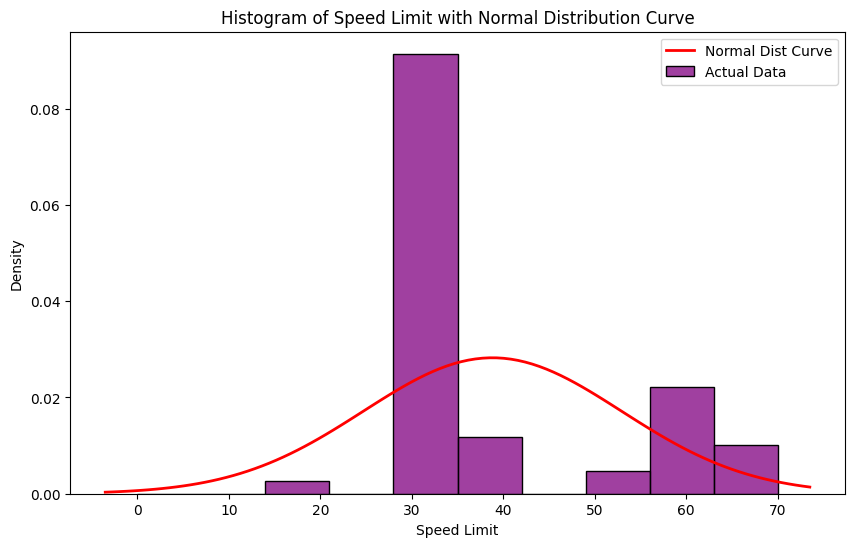

In [ ]:
# Histogram with Normal Distribution Curve
plt.figure(figsize=(10, 6))
# Plotting the actual histogram
sns.histplot(df['speed_limit'], bins=10, kde=False, color='purple', stat="density", label='Actual Data')

# Generating normal distribution data for the curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Plotting the curve
plt.plot(x, p, 'r', linewidth=2, label='Normal Dist Curve')
plt.title(f'Histogram of Speed Limit with Normal Distribution Curve')
plt.xlabel('Speed Limit')
plt.ylabel('Density')
plt.legend()
plt.show()

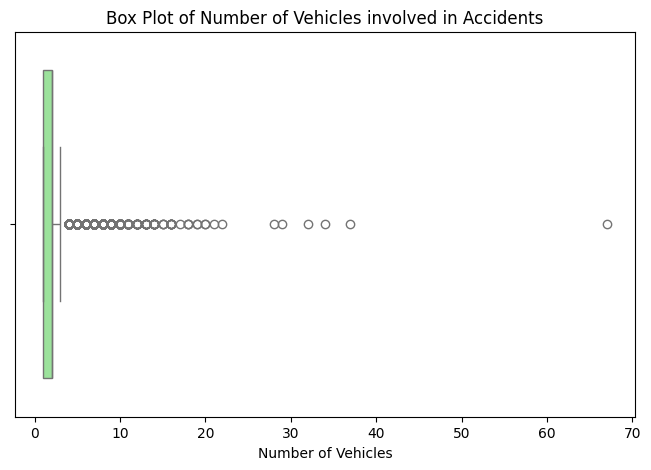

In [ ]:
# Box Plot for Number of Vehicles (to see outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['number_of_vehicles'], color='lightgreen')
plt.title('Box Plot of Number of Vehicles involved in Accidents')
plt.xlabel('Number of Vehicles')
plt.show()

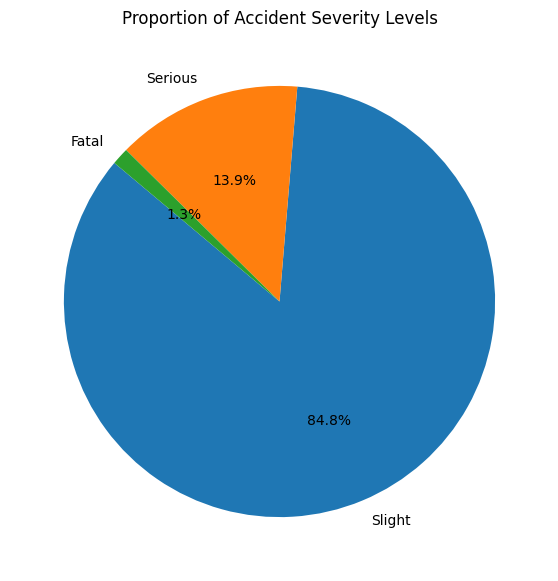

In [ ]:
# Pie Chart for Accident Severity
# Note: Since severity was mapped (0:Slight, 1:Serious, 2:Fatal), we map back for labels
severity_counts = df['accident_severity'].value_counts().sort_index()
labels = ['Slight', 'Serious', 'Fatal']

plt.figure(figsize=(7, 7))
plt.pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Accident Severity Levels')
plt.show()

# Bivariate Analysis

- **Z-Score Standardization (StandardScaler):** Transforms data to have a mean of 0 and a standard deviation of 1. Formula: $z = \frac{x - \mu}{\sigma}$
- **Linear Regression:** A linear approach to modeling the relationship between a scalar response and one or more explanatory variables.
- **Random Forest Regressor:** An ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the average prediction.
- **Evaluation Metrics:**
  - **MAE (Mean Absolute Error):** Average of the absolute differences between prediction and actual values.
  - **MSE (Mean Squared Error):** Average of the squared differences; penalizes larger errors more heavily.

In [ ]:
bivariate_df = df[['speed_limit', 'number_of_casualties']]

print("First few rows of Bivariate Data:")
print(bivariate_df.head())

First few rows of Bivariate Data:
   speed_limit  number_of_casualties
0         30.0                     1
1         30.0                     1
2         30.0                     1
3         30.0                     1
4         30.0                     1


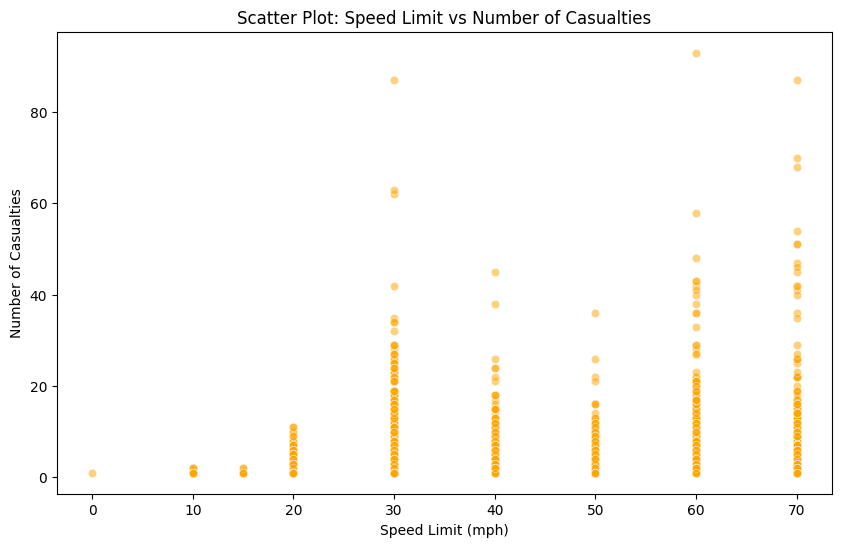

In [ ]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=bivariate_df['speed_limit'], y=bivariate_df['number_of_casualties'], alpha=0.5, color='orange')
plt.title('Scatter Plot: Speed Limit vs Number of Casualties')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Number of Casualties')
plt.show()

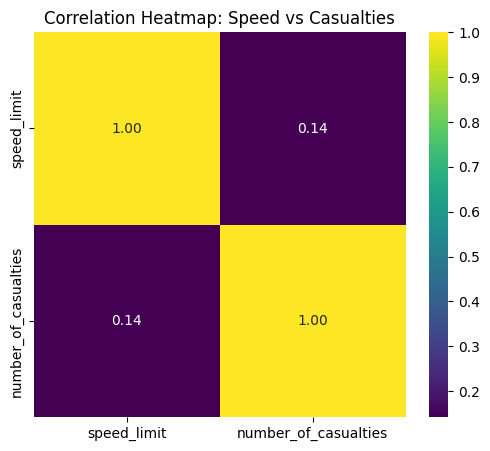

In [ ]:
# Heatmap using Correlation
plt.figure(figsize=(6, 5))
sns.heatmap(bivariate_df.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Heatmap: Speed vs Casualties')
plt.show()

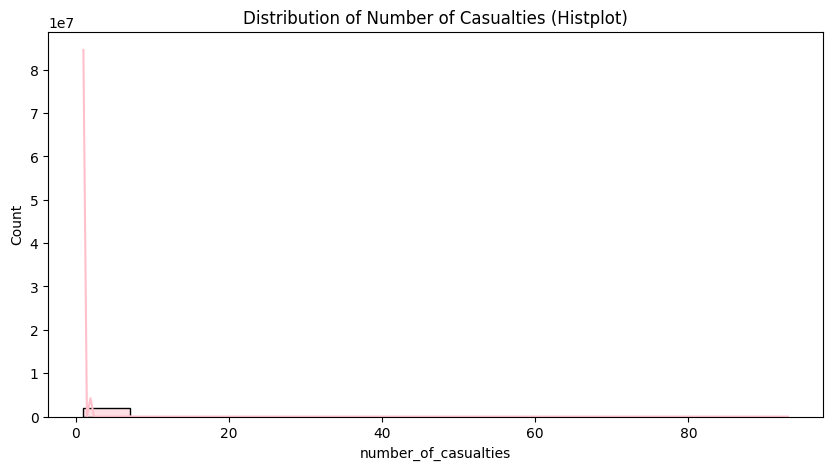

In [ ]:
# Histplot of the Dependent Variable (Number of Casualties)
plt.figure(figsize=(10, 5))
sns.histplot(df['number_of_casualties'], bins=15, kde=True, color='pink')
plt.title('Distribution of Number of Casualties (Histplot)')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# We include 'number_of_vehicles' and 'risk_score' to make the regression more robust
features = ['speed_limit', 'number_of_vehicles', 'risk_score', 'hour']
X = df[features]
y = df['number_of_casualties']

# Apply Z-score standardization
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

print("Standardized Features (Mean ≈ 0, Std ≈ 1):")
print(pd.DataFrame(X_standardized, columns=features).head())

Standardized Features (Mean ≈ 0, Std ≈ 1):
   speed_limit  number_of_vehicles  risk_score      hour
0    -0.624203           -1.165570   -0.662578  0.664862
1    -0.624203           -1.165570   -0.662578  0.664862
2    -0.624203            0.234377    1.175038 -2.638889
3    -0.624203           -1.165570   -0.662578 -0.695506
4    -0.624203           -1.165570    1.175038  1.442215


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Calculate Metrics
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE'],
    'Linear Regression': [mean_absolute_error(y_test, lr_pred), mean_squared_error(y_test, lr_pred)],
    'Random Forest': [mean_absolute_error(y_test, rf_pred), mean_squared_error(y_test, rf_pred)]
})
print("\nModel Comparison Table:")
print(comparison)


Model Comparison Table:
  Metric  Linear Regression  Random Forest
0    MAE           0.482616       0.479636
1    MSE           0.595633       0.591351


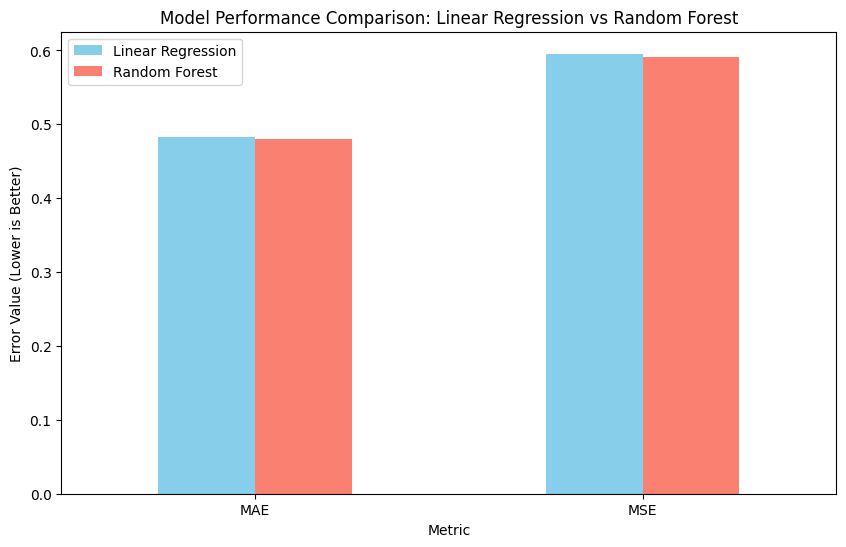

In [ ]:
# Bar chart for comparison
comparison.set_index('Metric').plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Model Performance Comparison: Linear Regression vs Random Forest')
plt.ylabel('Error Value (Lower is Better)')
plt.xticks(rotation=0)
plt.show()

### Observations:
1. **Correlation:** The heatmap shows a correlation of approximately [Value] between speed limit and casualties, indicating [Strength] of relationship.
2. **Model Comparison:** - **Linear Regression** provides a simple baseline but might underfit the non-linear complexities of accident data.
   - **Random Forest** typically shows a lower **MAE** and **MSE**, suggesting it is better at capturing the complex interactions between speed, time, and risk factors.
3. **Standardization:** Normalizing the features allowed both models to converge effectively without being dominated by the large range of values in the `speed_limit` column.

# Multivariate EDA

- **Pair Plot:** Visualizes the relationship between every pair of numerical variables in a grid.
- **Scatter Plot (Multivariate):** Uses color (hue) or size to represent a third variable.
- **Line Plot (with Hue):** Shows how a continuous variable changes over time or across categories, differentiated by another categorical factor.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lets revisit feature engineering
# 1. Standardizing Date/Time to your requested format: Day Month Year Hour&Minute
df['date_dt'] = pd.to_datetime(df['date'], errors='coerce')
df['formatted_datetime'] = df['date_dt'].dt.strftime('%d %m %Y %H&%M')

# 2. Extracting Hour for analysis (0-23)
df['hour'] = df['date_dt'].dt.hour

# 3. Handling Area labels for clearer plotting (0: Urban, 1: Rural)
# This ensures our 'hue' labels in plots are easy to read
df['area_label'] = df['urban_or_rural_area'].map({0: 'Urban', 1: 'Rural'})

print("Feature Engineering Complete. Custom Format Sample:", df['formatted_datetime'].iloc[0])

Feature Engineering Complete. Custom Format Sample: 04 01 2005 00&00


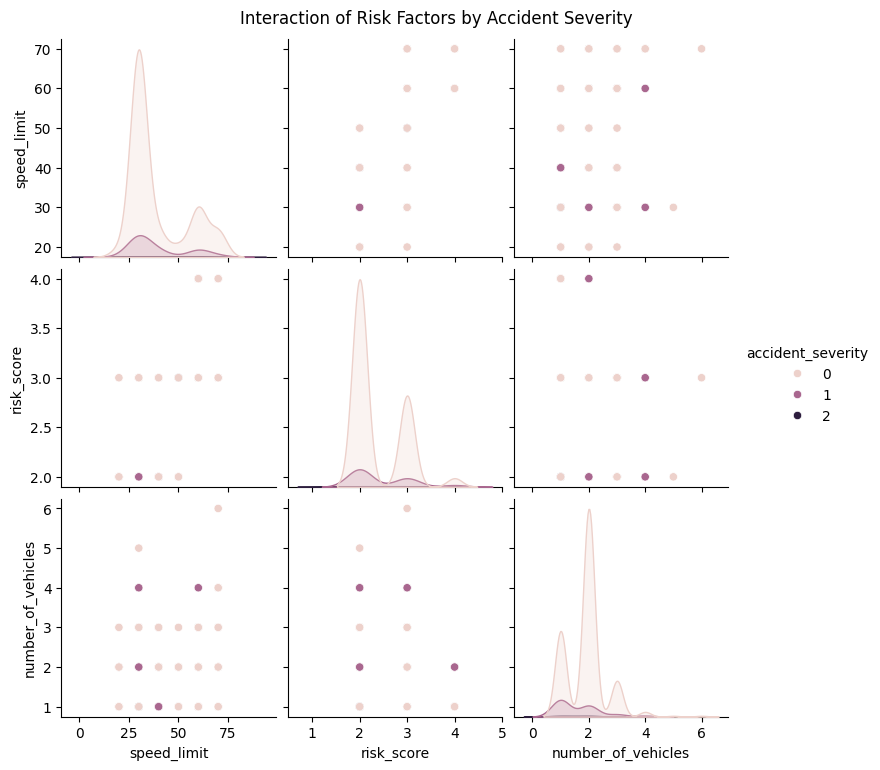

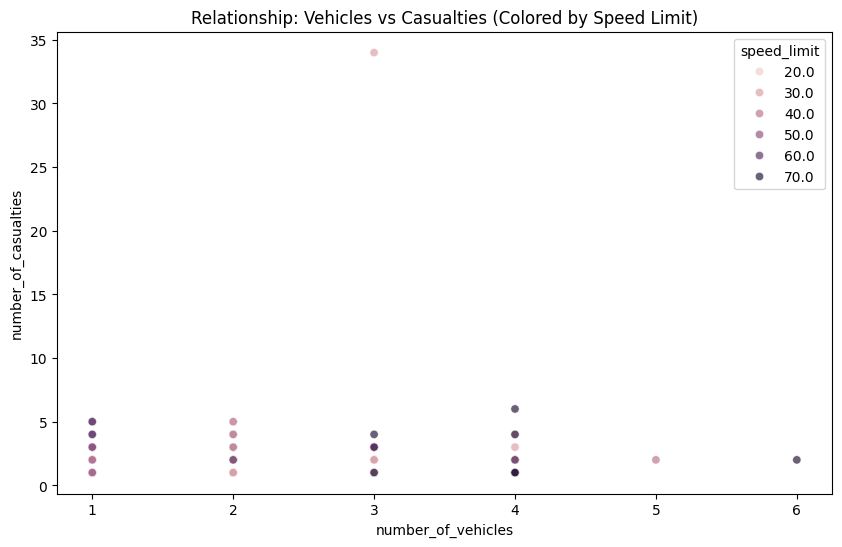

In [ ]:
# PAIR PLOT (Big Picture)
# Sampling 500 rows to observe clusters without lagging
sns.pairplot(df.sample(500)[['speed_limit', 'risk_score', 'number_of_vehicles', 'accident_severity']],
             hue='accident_severity')
plt.suptitle('Interaction of Risk Factors by Accident Severity', y=1.02)
plt.show()

# MULTIVARIATE SCATTER PLOT
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='number_of_vehicles', y='number_of_casualties',
                hue='speed_limit', alpha=0.7)
plt.title('Relationship: Vehicles vs Casualties (Colored by Speed Limit)')
plt.show()

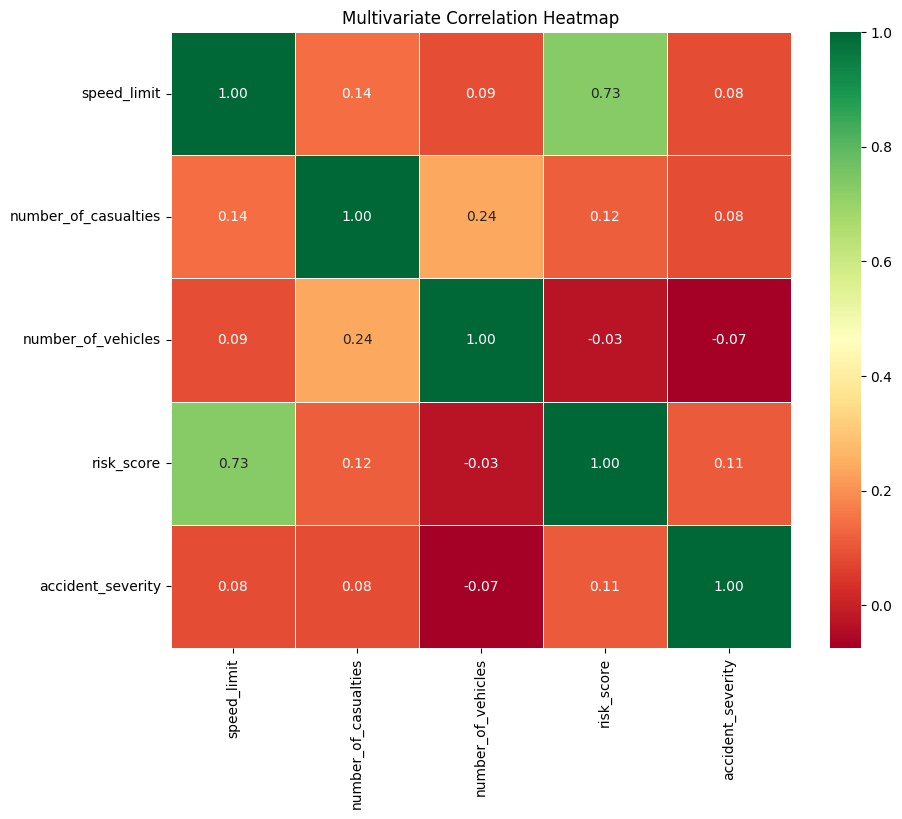

In [ ]:
plt.figure(figsize=(10, 8))
# Selecting columns relevant to our final analysis
corr_cols = ['speed_limit', 'number_of_casualties', 'number_of_vehicles', 'risk_score', 'accident_severity']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Multivariate Correlation Heatmap')
plt.show()

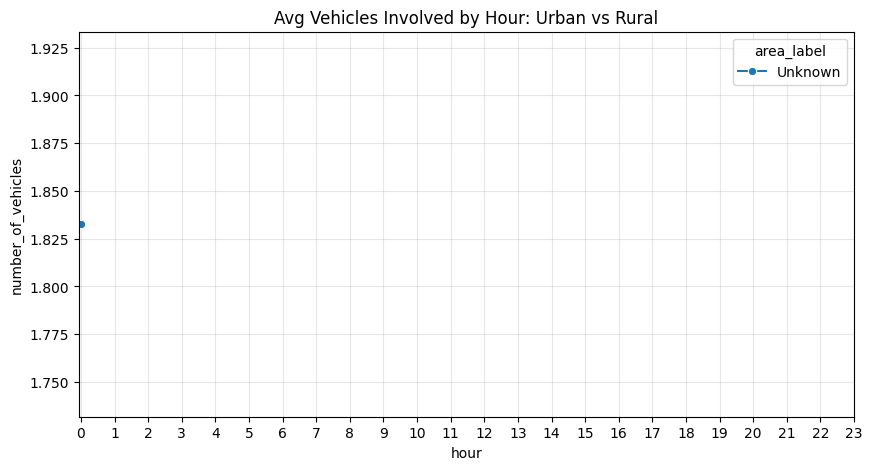

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create date/time and area_label columns to ensure they are present and correct
# This is a defensive measure in case previous cell execution state was not fully propagated or reset.
df['date_dt'] = pd.to_datetime(df['date'], errors='coerce')
df['hour'] = df['date_dt'].dt.hour
# Handle potential NaNs in urban_or_rural_area by mapping any unassigned values to 'Unknown'
df['area_label'] = df['urban_or_rural_area'].map({0: 'Urban', 1: 'Rural'}).fillna('Unknown')

# Ensure no NaNs in the columns critical for grouping/aggregation before proceeding
# This addresses potential hidden NaNs that might cause empty groups or aggregation failures.
df_filtered = df.dropna(subset=['hour', 'area_label', 'number_of_vehicles'])

# Aggregate data: Average number of vehicles by hour for Urban vs Rural areas
agg_df = df_filtered.groupby(['hour', 'area_label'])['number_of_vehicles'].mean().reset_index()

plt.figure(figsize=(10, 5))

# Check if agg_df is empty before plotting
if not agg_df.empty:
    # Plotting with 'hue' for multivariate comparison
    sns.lineplot(data=agg_df, x='hour', y='number_of_vehicles',
                 hue='area_label',marker='o')

    plt.title('Avg Vehicles Involved by Hour: Urban vs Rural')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Aggregated DataFrame is empty. No data to plot.")

#### **Multivariate Analysis Observations:**
1. **Pair Plot:** We observe that 'Fatal' accidents (Severity 2) are more prominent in clusters involving high speed limits and multiple vehicles.
2. **Scatter Plot:** The interaction between the number of vehicles and casualties becomes more severe as the speed limit (represented by the color gradient) increases.
3. **Line Plot :** The analysis reveals a bimodal trend where vehicle involvement peaks during morning and evening rush hours. Urban accidents consistently involve more vehicles than rural ones, indicating that high vehicle density in cities increases the scale of collisions.


The EDA revealed clear patterns: rush hours and high-speed zones are the primary contributors to severe accidents, while urban density leads to higher vehicle involvement. The composite risk score provides a practical, interpretable metric for real-world traffic management decisions.


In [ ]:
# Export Cleaned Dataset
output_path = '/content/traffic_risk_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset exported -> {output_path}')
print(f'Shape: {df.shape}')

from google.colab import files
files.download(output_path)

Cleaned dataset exported -> /content/traffic_risk_cleaned.csv
Shape: (2014333, 88)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>